In [ ]:
import pandas as pd
import glob
import os

data_dir = "data" 

# 1. Load ONLY the ratings data files (fixed search pattern)
ratings_files = glob.glob(os.path.join(data_dir, '**', 'ratings-*.tsv'), recursive=True)

suggestion_rows = []
unique_raters_all = set()
unique_raters_with_suggestions = set()

print(f"Found {len(ratings_files)} ratings TSV files. Running optimized extraction...\n")

for f in ratings_files:
    print(f"Checking {os.path.basename(f)}...")
    
    # Peek at the columns in the first row without loading the whole file
    try:
        sample_df = pd.read_csv(f, sep='\t', nrows=0)
        columns = sample_df.columns.tolist()
    except Exception as e:
        print(f"  Could not read header: {e}")
        continue

    # Safely determine the rater column, or skip if neither exists
    if 'raterParticipantId' in columns:
        rater_col = 'raterParticipantId'
    elif 'participantId' in columns:
        rater_col = 'participantId'
    else:
        print("  -> Skipping: No valid participant ID column found in this file.")
        continue
    
    # If the file doesn't have the new suggestion column, we only need to count its raters
    if 'suggestion' not in columns:
        print("  -> No 'suggestion' column found. Counting total raters only...")
        # Read ONLY the rater column to save time
        chunk_iter = pd.read_csv(f, sep='\t', usecols=[rater_col], chunksize=500000)
        for chunk in chunk_iter:
            unique_raters_all.update(chunk[rater_col].dropna().unique())
        continue
        
    print("  -> 'suggestion' column found! Extracting suggestions...")
    # Read ONLY the 3 columns we need. This makes it blazing fast.
    cols_to_use = ['noteId', rater_col, 'suggestion']
    
    chunk_iter = pd.read_csv(f, sep='\t', usecols=cols_to_use, chunksize=500000, low_memory=False)
    
    for chunk in chunk_iter:
        unique_raters_all.update(chunk[rater_col].dropna().unique())
        
        # Keep only rows where 'suggestion' is not null and not empty
        has_suggestion = chunk[chunk['suggestion'].notna() & (chunk['suggestion'] != '')]
        
        if not has_suggestion.empty:
            suggestion_rows.append(has_suggestion)
            unique_raters_with_suggestions.update(has_suggestion[rater_col].unique())

# Combine all isolated suggestion rows into one DataFrame
df_suggestions = pd.concat(suggestion_rows, ignore_index=True) if suggestion_rows else pd.DataFrame()
print(f"\nDone! Total suggestions found: {len(df_suggestions)}")

Found 8 ratings TSV files. Running optimized extraction...

Checking ratings-00000.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00001.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00007.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00006.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00005.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00004.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00003.tsv...
  -> 'suggestion' column found! Extracting suggestions...
Checking ratings-00002.tsv...
  -> 'suggestion' column found! Extracting suggestions...

Done! Total suggestions found: 3869


In [ ]:
# 1. Take a random sample of 100 suggestions
sample_100 = df_suggestions.sample(n=100, random_state=42)

# 2. Extract noteId and tweetId from the notes files
print("Fetching tweetIds from notes dataset...")
notes_files = glob.glob(os.path.join(data_dir, '**', 'notes-*.tsv'), recursive=True)

if not notes_files:
    print("Warning: No 'notes-*.tsv' files found! Please make sure you unzipped the notes data.")
else:
    # Fast extraction: only pull 'noteId' and 'tweetId'
    df_notes_subset = pd.concat(
        [pd.read_csv(f, sep='\t', usecols=['noteId', 'tweetId'], low_memory=False) for f in notes_files], 
        ignore_index=True
    )

    # 3. Merge to attach the tweetId to our 100 samples
    final_sample = pd.merge(sample_100, df_notes_subset, on='noteId', how='left')

    # 4. Format the final output sheet 
    output_df = final_sample[['tweetId', 'noteId', 'suggestion']].copy()
    
   
    output_df['Axis 1 (e.g., Task Oriented)'] = ""
    output_df['Axis 2 (e.g., Role Oriented)'] = ""

    # 5. Export to CSV 
    output_path = os.path.join(data_dir, "taxonomy_100_sample.csv")
    output_df.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Saved 100 random suggestions to: {output_path}")

Fetching tweetIds from notes dataset...

Success! Saved 100 random suggestions to: data\taxonomy_100_sample.csv


Visualizations saved to: data\step2_visualizations.png



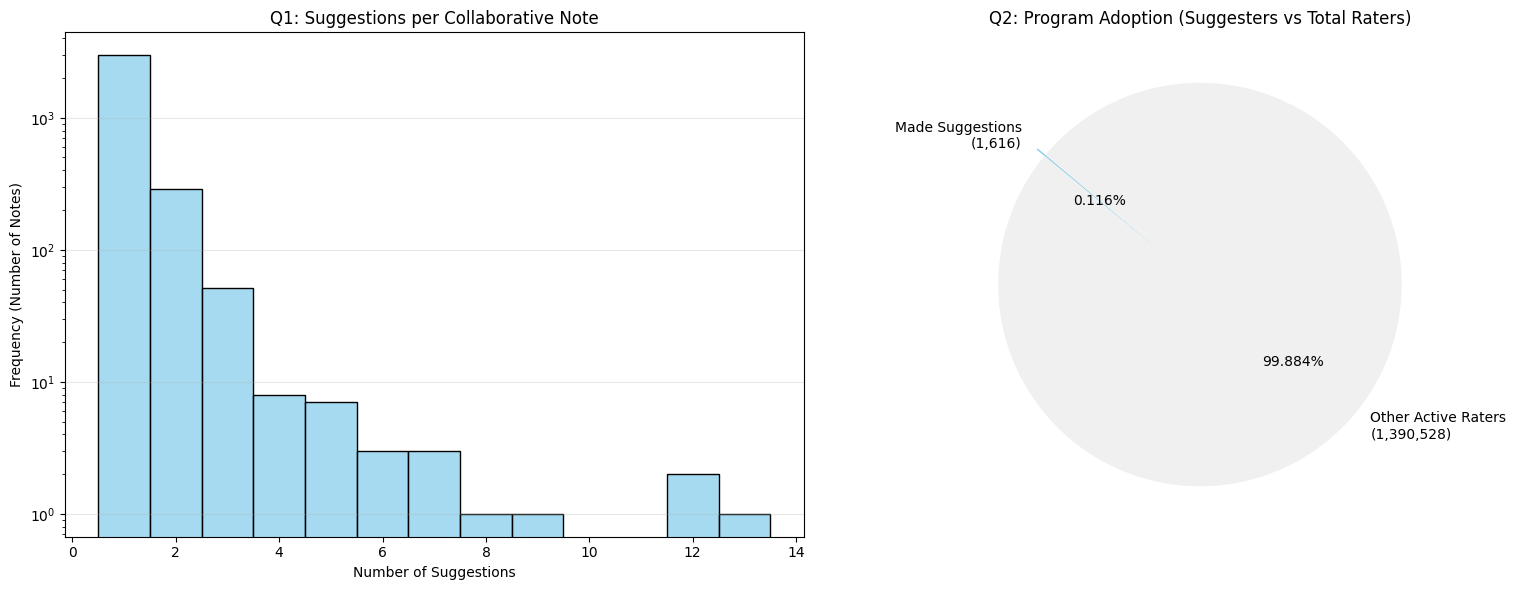

--- Data for Written Report ---
Max suggestions on a single note: 13
Average suggestions per note: 1.16
Total people making suggestions: 1,616


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# Q1: Distribution of Suggestions per Note
# ==========================================
suggestions_per_note = df_suggestions.groupby('noteId').size()

# Use discrete=True for integer bins so the bars line up nicely
sns.histplot(suggestions_per_note, color='skyblue', ax=ax1, discrete=True)
ax1.set_title('Q1: Suggestions per Collaborative Note')
ax1.set_xlabel('Number of Suggestions')
ax1.set_ylabel('Frequency (Number of Notes)')
ax1.set_yscale('log') # Log scale because a few notes have many suggestions
ax1.grid(axis='y', alpha=0.3)

# ==========================================
# Q2: Are we bringing in more people?
# ==========================================
total_raters = len(unique_raters_all)
active_suggesters = len(unique_raters_with_suggestions)
non_suggesters = total_raters - active_suggesters

# Pie chart data
labels = [f'Made Suggestions\n({active_suggesters:,})', f'Other Active Raters\n({non_suggesters:,})']
sizes = [active_suggesters, non_suggesters]

colors = ['skyblue', '#f0f0f0'] 
explode = (0.05, 0)  

ax2.pie(sizes, explode=explode, labels=labels, colors=colors, 
        autopct='%1.3f%%', shadow=False, startangle=140) # shadow=False removes the 3D look
ax2.set_title('Q2: Program Adoption (Suggesters vs Total Raters)')

# Tidy up layout and save
plt.tight_layout()
plot_path = os.path.join(data_dir, "step2_visualizations.png")
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

print(f"Visualizations saved to: {plot_path}\n")
plt.show()

# Print the concrete numbers 
print("--- Data for Written Report ---")
print(f"Max suggestions on a single note: {suggestions_per_note.max()}")
print(f"Average suggestions per note: {suggestions_per_note.mean():.2f}")
print(f"Total people making suggestions: {active_suggesters:,}")

In [ ]:
import pandas as pd
import glob
import os
import re

data_dir = "data"

# ---------------------------------------------------------
# 1. Calculate % of suggestions with a link in them
# ---------------------------------------------------------
# A simple regex to detect "http://" or "https://"
url_pattern = r'https?://[^\s]+'
df_suggestions['has_link'] = df_suggestions['suggestion'].str.contains(url_pattern, case=False, na=False, regex=True)

total_suggestions = len(df_suggestions)
suggestions_with_links = df_suggestions['has_link'].sum()
pct_with_links = (suggestions_with_links / total_suggestions) * 100 if total_suggestions > 0 else 0

print("--- Quantitative Analysis ---")
print(f"Total Suggestions: {total_suggestions:,}")
print(f"Suggestions with Links: {suggestions_with_links:,}")
print(f"Percentage of suggestions with links: {pct_with_links:.2f}%\n")

# ---------------------------------------------------------
# 2. Calculate % that result in a new version (new noteId on same tweetId)
# ---------------------------------------------------------
print("Loading notes dataset to check for multiple versions...")
notes_files = glob.glob(os.path.join(data_dir, '**', 'notes-*.tsv'), recursive=True)

# Note: The Community Notes dataset usually uses 'summary' for the actual text of the note. 
# We load noteId, tweetId, and summary so we can read the text later.
df_notes = pd.concat(
    [pd.read_csv(f, sep='\t', usecols=['noteId', 'tweetId', 'summary'], low_memory=False) for f in notes_files], 
    ignore_index=True
)

# Merge tweetId into our suggestions dataframe
df_suggestions = df_suggestions.merge(df_notes[['noteId', 'tweetId']].drop_duplicates(), on='noteId', how='left')

# Find tweetIds that have MORE THAN ONE noteId attached to them (meaning it was updated/rewritten)
notes_per_tweet = df_notes.groupby('tweetId')['noteId'].nunique()
tweets_with_updates = notes_per_tweet[notes_per_tweet > 1].index.tolist()

# Isolate the suggestions that had links
linked_suggestions = df_suggestions[df_suggestions['has_link']]

# Out of those linked suggestions, how many belong to a tweet that got updated?
linked_suggestions_with_updates = linked_suggestions[linked_suggestions['tweetId'].isin(tweets_with_updates)]

pct_updates = (len(linked_suggestions_with_updates) / len(linked_suggestions)) * 100 if len(linked_suggestions) > 0 else 0

print(f"Linked suggestions that resulted in a new note version: {len(linked_suggestions_with_updates):,}")
print(f"Percentage of linked suggestions resulting in an update: {pct_updates:.2f}%\n")

# ---------------------------------------------------------
# 3. Qualitative Examples 
# ---------------------------------------------------------
print("--- Qualitative Examples to Review ---")
print("Here are 3 random examples where a user provided a link, and the note was updated.")

# Grab 3 random examples (or fewer if there aren't 3)
sample_size = min(3, len(linked_suggestions_with_updates))
sample_examples = linked_suggestions_with_updates.sample(n=sample_size, random_state=42)

for i, row in sample_examples.iterrows():
    t_id = row['tweetId']
    print(f"==== TWEET ID: {t_id} ====")
    print(f"USER SUGGESTION: {row['suggestion']}\n")
    
    # Get all notes for this tweet to see if the AI incorporated the link
    tweet_notes = df_notes[df_notes['tweetId'] == t_id]
    print(f"AI DRAFTS ON THIS TWEET ({len(tweet_notes)} versions found):")
    for j, note_row in tweet_notes.iterrows():
        # Print the first 250 characters of the note to see if the link/info was added
        snippet = str(note_row['summary'])[:250].replace('\n', ' ')
        print(f" - [Note {note_row['noteId']}]: {snippet}...")
    print("\n")

--- Quantitative Analysis ---
Total Suggestions: 3,869
Suggestions with Links: 596
Percentage of suggestions with links: 15.40%

Loading notes dataset to check for multiple versions...
Linked suggestions that resulted in a new note version: 4
Percentage of linked suggestions resulting in an update: 0.67%

--- Qualitative Examples to Review ---
Here are 3 random examples where a user provided a link, and the note was updated.
Read these to answer the 'qualitative' part of your assignment:

==== TWEET ID: 2.0219761956303053e+18 ====
USER SUGGESTION: While it is true this AI doesn't predict breast cancer, the tweet mentions &quot;5 years before it develops&quot;, not before it happens. This AI is designed to detect breast cancer before it develops and is more difficult to treat.    Original tweet: https://x.com/i/status/2021976195630305280

AI DRAFTS ON THIS TWEET (10 versions found):
 - [Note 2022338915827384571]: NNN     AI doesn't just &quot;predict&quot; risk; it detects existing pre-